++ Read in data array with dimensions: 60, 67, 144
   The first two are spatial dimensions, and the third is time.
++ Read in reference time series of length: 144
Shape 1D : (4020,)
Shape after reconstruction (60, 67)
reconstruction matches orginal:  True


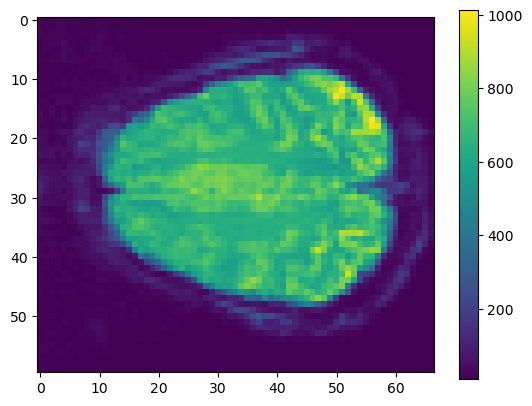

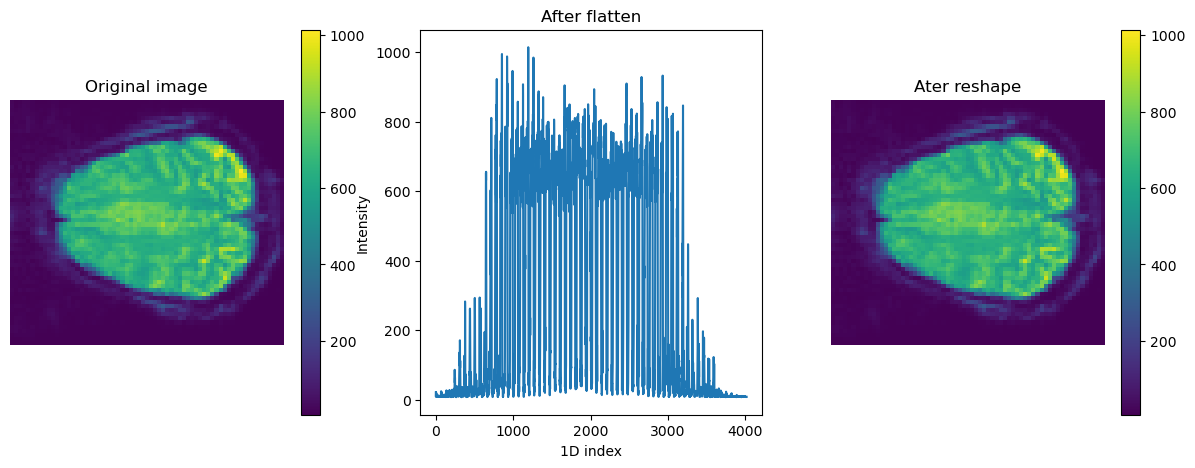

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================================================
# background functions: provided to read data

def read_in_dataset(fname):
    """
Parameters
----------
fname_dat : str
    filename of data (of the particular dimensions included in this function)

Returns
-------
data : np.ndarray
    3D array of data, representing a slice of data (first 2 coords) and a time
    series at each location (3rd dimension)
"""

    # read in: brain time series data
    fff = open(fname, "r")
    X = fff.readlines()
    fff.close()
    brain = [line.split() for line in X]

    # dimensions of brain data (slice + time)
    N = 144
    dimx = 70-11+1
    dimy = 74-8+1

    # brain data: initialize+populate
    data = np.zeros((dimx,dimy,N))
    n = 0
    for j in range(0,dimy):
        for i in range(0,dimx):
            for k in range(0,N):
                # don't need these coord values, but just keep track
                x = brain[n][0]
                y = brain[n][1]
                z = brain[n][2]
                data[i,j,k] = brain[n][3+k]
            n+=1

    Nx, Ny, Nt = np.shape(data)

    print("++ Read in data array with dimensions: {}, {}, {}\n"
          "   The first two are spatial dimensions, and the third is time."
          "".format(Nx, Ny, Nt))

    return data

def read_in_refwav(fname):
    """Read in a file fname that contains a single reference time series.

Parameters
----------
fname_ref : str
    filename of reference wave (of particular len included in this function)

Returns
-------
refwav : np.ndarray
    1D array of data, representing reference time series
"""

    # read in: brain time series data
    fff = open(fname, "r")
    X = fff.readlines()
    fff.close()
    boxcar = [line.split() for line in X]

    # dimensions of reference wave (number of time points)
    N = len(boxcar)

    # make refwav
    refwav = np.zeros(N)
    for k in range(0,N):
        refwav[k] = boxcar[k][0]

    print("++ Read in reference time series of length: {}"
          "".format(N))

    return refwav

# =========================================================================

if __name__ == "__main__":
    
    # read in a slice of FMRI data (3D array): first 2 dims are
    # spatial indices, and third is index of time points
    data = read_in_dataset("AIMSftap.dat")
    Nx, Ny, Nt = np.shape(data)

    # the sampling time for this data
    Ts = 2.5

    # read in a reference time series (1D array)
    refwav = read_in_refwav("Ref.1D")
    L = len(refwav)    

    data_mean = np.zeros((Nx, Ny))
    for i in range(Nx):
        for j in range(Ny):
            data_mean[i,j] = np.mean(data[i,j,:])

    #flaten 
    data_flat = data_mean.flatten()
    print(f"Shape 1D : {data_flat.shape}")

    #reshape
    data_reconstructed = data_flat.reshape(Nx,Ny)
    print(f"Shape after reconstruction {data_reconstructed.shape}")

    are_equal = np.allclose(data_mean, data_reconstructed)
    print(f"reconstruction matches orginal:  {are_equal}")
    plt.imshow(data_mean)
    plt.colorbar()
    plt.show()


    #visual 
    fig, axes = plt.subplots(1,3, figsize = (15,5))
    im0 = axes[0].imshow(data_mean)
    axes[0].set_title('Original image')
    axes[0].axis('off')
    plt.colorbar(im0, ax = axes[0])


    axes[1].plot(data_flat)
    axes[1].set_title("After flatten")
    axes[1].set_xlabel('1D index')
    axes[1].set_ylabel('Intensity')

    im2 = axes[2].imshow(data_reconstructed)
    axes[2].set_title("Ater reshape")
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])

    print("")

4020